# Assignment 12 — ZeRO on 32 virtual GPUs

**A runnable CPU experiment: identical model, data, global batch, and Adam updates;
different ownership of parameters, gradients, and optimizer state.**

[GitHub repository](https://github.com/shankarpandala/era-v5) ·
[Detailed README](https://github.com/shankarpandala/era-v5/tree/codex/assignment-12-zero-simulation/assignment-12) ·
[Open in Colab](https://colab.research.google.com/github/shankarpandala/era-v5/blob/codex/assignment-12-zero-simulation/assignment-12/zero_simulation.ipynb)

Run **Runtime → Run all** in Colab (CPU is sufficient), or `python run_demo.py` locally.
Everything needed to train is embedded below. No datasets, weights, GPU runtime,
DeepSpeed installation, or repository clone are needed. NumPy and Matplotlib are
preinstalled in Colab; local dependencies are in `requirements.txt`.

We construct **32 independent virtual ranks**, schedule their real matrix operations
on a pool of up to **32 CPU threads**, and numerically perform the collectives in a
coordinator. This demonstrates the state partitioning algorithm. There are no CUDA
devices or actual network transfers. Memory below means explicitly owned NumPy
tensor payload; network bytes and large-model projections are analytical.

## 1. What changes across stages?

| Mode | Parameters | Gradient buffer | Adam moments | Communication schedule |
|---|---|---|---|---|
| DDP baseline | replicated | replicated | replicated | gradient all-reduce |
| ZeRO-1 | replicated | replicated | sharded | gradient reduce-scatter; updated parameter all-gather |
| ZeRO-2 | replicated | sharded | sharded | layer gradient reduce-scatter; updated parameter all-gather |
| ZeRO-3 | sharded | sharded | sharded | layer all-gather forward + backward; gradient reduce-scatter |

A **reduce-scatter** averages the 32 local gradient contributions and gives each
owner its slice. An **all-gather** reconstructs a tensor from those slices.
The coordinator implements these numerically with NumPy; the communication ledger
models the bytes a ring implementation would send.

Stage 1 retains a full local gradient buffer even though only each owner's reduced
slice is needed for Adam. Stage 2 releases each temporary layer gradient after its
reduction. Stage 3 additionally releases gathered parameters after each layer, then
gathers them again for backward. No activation checkpointing, offload, communication
overlap, or parameter persistence optimization is enabled.

In [1]:
import os
for variable in ('OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'OMP_NUM_THREADS',
                 'VECLIB_MAXIMUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[variable] = '1'
from pathlib import Path
import json, platform, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ART = Path(os.environ.get('A12_ART_DIR', 'submission_artifacts'))
(ART / 'plots').mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
COLORS = ['#64748b', '#2563eb', '#059669', '#9333ea']
print(f'Python {sys.version.split()[0]} | NumPy {np.__version__} | '
      f'Matplotlib {matplotlib.__version__} | {platform.platform()}')
print(f'Physical-host logical CPUs: {os.cpu_count()} | virtual ranks: 32 | thread pool: 32')
print('Arithmetic: float64; Adam stores two float64 moments, with no master weight copy.')

Python 3.13.13 | NumPy 2.4.4 | Matplotlib 3.11.1 | macOS-27.0-arm64-arm-64bit-Mach-O
Physical-host logical CPUs: 15 | virtual ranks: 32 | thread pool: 32
Arithmetic: float64; Adam stores two float64 moments, with no master weight copy.


## 2. The runnable simulator

The next cell contains the complete engine, also available as `zero_simulator.py`
for inspection and tests. It performs a three-layer MLP's forward pass, mean squared
error, manual backward pass, and Adam update. Every rank receives eight different
examples from the same deterministic 256-example teacher regression dataset.
Each step covers the entire dataset; every mode starts from the same weights.

Layers are flattened separately and zero-padded to a multiple of 32. Padding
participates in storage and collective counts, but cannot affect predictions.
Backward uses pre-update parameters. All updates occur after backward has finished.

In [2]:
"""A numerical, CPU-thread simulation of ZeRO stages 0, 1, 2 and 3.

Virtual ranks own real NumPy parameter, gradient and Adam-state buffers. The
coordinator performs mathematically correct collectives in process; network
traffic is an analytic ideal-ring estimate, NOT measured network traffic.

Memory means ndarray payload bytes for explicitly tracked rank-owned buffers.
It excludes datasets, the coordinator's reduction/gather scratch, Python object
overhead, NumPy/BLAS internal workspaces and allocator/RSS overhead. Consequently
it must not be presented as a process RSS or physical GPU peak measurement.
"""

from __future__ import annotations

from collections import Counter
from concurrent.futures import ThreadPoolExecutor
from dataclasses import asdict, dataclass, field
import os
import threading
import time
from typing import Callable

import numpy as np


DTYPE = np.float64
ITEMSIZE = np.dtype(DTYPE).itemsize
BETA1, BETA2, EPSILON = 0.9, 0.999, 1e-8
STAGE_NAMES = {0: "DDP baseline", 1: "ZeRO-1", 2: "ZeRO-2", 3: "ZeRO-3"}


@dataclass(frozen=True)
class Config:
    """Small defaults keep the complete 32-rank demonstration CPU friendly."""

    world_size: int = 32
    dims: tuple[int, ...] = (32, 64, 64, 16)
    local_batch: int = 8
    steps: int = 40
    learning_rate: float = 0.01
    seed: int = 12
    workers: int = 32

    def __post_init__(self) -> None:
        object.__setattr__(self, "dims", tuple(self.dims))
        for name in ("world_size", "local_batch", "steps", "workers"):
            value = getattr(self, name)
            if not isinstance(value, int) or isinstance(value, bool) or value < 1:
                raise ValueError(f"{name} must be a positive integer")
        if len(self.dims) < 2 or any(
            not isinstance(d, int) or isinstance(d, bool) or d < 1 for d in self.dims
        ):
            raise ValueError("dims must contain at least two positive integers")
        if not np.isfinite(self.learning_rate) or self.learning_rate <= 0:
            raise ValueError("learning_rate must be finite and positive")


@dataclass(frozen=True)
class LayerLayout:
    input_size: int
    output_size: int
    parameter_count: int
    padded_count: int
    shard_count: int


def layer_layouts(config: Config) -> list[LayerLayout]:
    result = []
    for fan_in, fan_out in zip(config.dims[:-1], config.dims[1:]):
        count = (fan_in + 1) * fan_out
        padded = ((count + config.world_size - 1) // config.world_size) * config.world_size
        result.append(LayerLayout(fan_in, fan_out, count, padded, padded // config.world_size))
    return result


def _unpack(flat: np.ndarray, layout: LayerLayout) -> tuple[np.ndarray, np.ndarray]:
    weights_count = layout.input_size * layout.output_size
    return (
        flat[:weights_count].reshape(layout.input_size, layout.output_size),
        flat[weights_count:layout.parameter_count],
    )


def make_problem(config: Config) -> tuple[list[np.ndarray], list[np.ndarray], list[np.ndarray]]:
    """Return padded initial layers and independent, fixed per-rank X/Y arrays.

    A seeded teacher MLP supplies deterministic regression targets. All stages
    receive the same initialization and global batch, reused at every step so
    loss curves and parameter comparisons isolate the sharding algorithm.
    """
    rng = np.random.default_rng(config.seed)
    initial, teacher = [], []
    layouts = layer_layouts(config)
    for layout in layouts:
        flat = np.zeros(layout.padded_count, dtype=DTYPE)
        weights, _ = _unpack(flat, layout)
        weights[:] = rng.normal(0, np.sqrt(1.0 / layout.input_size), weights.shape)
        initial.append(flat)
        teacher_flat = np.zeros_like(flat)
        teacher_w, teacher_b = _unpack(teacher_flat, layout)
        teacher_w[:] = rng.normal(0, np.sqrt(1.0 / layout.input_size), teacher_w.shape)
        teacher_b[:] = rng.normal(0, 0.1, teacher_b.shape)
        teacher.append(teacher_flat)
    inputs, targets = [], []
    for _ in range(config.world_size):
        x = rng.normal(size=(config.local_batch, config.dims[0])).astype(DTYPE)
        y = x
        for index, (flat, layout) in enumerate(zip(teacher, layouts)):
            weights, bias = _unpack(flat, layout)
            y = y @ weights + bias
            if index < len(layouts) - 1:
                y = np.tanh(y)
        inputs.append(x)
        targets.append(y.copy())
    return initial, inputs, targets


def loss_and_grad(
    parameters: list[np.ndarray], x: np.ndarray, y: np.ndarray, dims: tuple[int, ...]
) -> tuple[float, list[np.ndarray]]:
    """Ordinary unsharded MLP reference; padding has zero gradient."""
    layouts = [
        LayerLayout(a, b, (a + 1) * b, len(p), len(p))
        for a, b, p in zip(dims[:-1], dims[1:], parameters)
    ]
    activations = [x]
    for index, (flat, layout) in enumerate(zip(parameters, layouts)):
        weights, bias = _unpack(flat, layout)
        out = activations[-1] @ weights + bias
        activations.append(np.tanh(out) if index < len(layouts) - 1 else out)
    delta = activations[-1] - y
    loss = float(np.mean(delta * delta))
    delta *= 2.0 / delta.size
    gradients = [np.zeros_like(p) for p in parameters]
    for index in range(len(layouts) - 1, -1, -1):
        weights, _ = _unpack(parameters[index], layouts[index])
        grad_w, grad_b = _unpack(gradients[index], layouts[index])
        grad_w[:] = activations[index].T @ delta
        grad_b[:] = delta.sum(axis=0)
        if index:
            delta = (delta @ weights.T) * (1.0 - activations[index] ** 2)
    return loss, gradients


def full_batch_reference(config: Config) -> dict:
    """Single global-batch Adam reference, outside virtual-rank timing/memory."""
    parameters, inputs, targets = make_problem(config)
    x, y = np.concatenate(inputs), np.concatenate(targets)
    first = [np.zeros_like(p) for p in parameters]
    second = [np.zeros_like(p) for p in parameters]
    losses = []
    for step in range(1, config.steps + 1):
        loss, gradients = loss_and_grad(parameters, x, y, config.dims)
        losses.append(loss)
        for p, g, m, v in zip(parameters, gradients, first, second):
            m *= BETA1
            m += (1.0 - BETA1) * g
            v *= BETA2
            v += (1.0 - BETA2) * g * g
            p -= config.learning_rate * (m / (1.0 - BETA1**step)) / (
                np.sqrt(v / (1.0 - BETA2**step)) + EPSILON
            )
    final_loss, _ = loss_and_grad(parameters, x, y, config.dims)
    return {"loss_curve": losses, "final_loss": final_loss, "parameters": parameters}


@dataclass
class RankState:
    """The storage owned by one virtual GPU; arrays never alias another rank."""

    rank: int
    inputs: np.ndarray
    targets: np.ndarray
    parameters: list[np.ndarray]
    gradients: list[np.ndarray]
    first_moment: list[np.ndarray]
    second_moment: list[np.ndarray]
    activations: list[np.ndarray] = field(default_factory=list)
    materialized_layer: np.ndarray | None = None
    local_gradient: np.ndarray | None = None
    delta: np.ndarray | None = None
    next_delta: np.ndarray | None = None
    derivative_workspace: np.ndarray | None = None
    optimizer_workspace: list[np.ndarray] = field(default_factory=list)
    peak_tracked_bytes: int = 0
    peak_transient_bytes: int = 0
    transient_component_peaks: dict = field(default_factory=dict)
    worker_ids: set = field(default_factory=set)

    def state_bytes(self) -> dict[str, int]:
        result = {
            name: sum(array.nbytes for array in getattr(self, name))
            for name in ("parameters", "gradients", "first_moment", "second_moment")
        }
        result["total"] = sum(result.values())
        return result

    def observe(self) -> None:
        # The input batch is data, not an activation allocation. All other
        # entries here own independent buffers; views are not counted twice.
        transient = {
            "activation_cache": sum(a.nbytes for a in self.activations[1:]),
            "materialized_layer": 0 if self.materialized_layer is None else self.materialized_layer.nbytes,
            "local_gradient": 0 if self.local_gradient is None else self.local_gradient.nbytes,
            "backprop_signals": sum(a.nbytes for a in (self.delta, self.next_delta) if a is not None),
            "derivative_workspace": 0 if self.derivative_workspace is None else self.derivative_workspace.nbytes,
            "optimizer_workspace": sum(a.nbytes for a in self.optimizer_workspace),
        }
        transient_total = sum(transient.values())
        self.peak_transient_bytes = max(self.peak_transient_bytes, transient_total)
        self.peak_tracked_bytes = max(self.peak_tracked_bytes, self.state_bytes()["total"] + transient_total)
        for name, value in transient.items():
            self.transient_component_peaks[name] = max(self.transient_component_peaks.get(name, 0), value)


class Simulator:
    """One ZeRO stage, numerical collectives, and a configurable thread pool.

    The executor schedules logical ranks onto CPU threads; it does not promise
    32 simultaneous OS threads or assign a permanent thread to each rank.
    A stage-3 rank retains only parameter shards between module operations.
    """

    def __init__(self, config: Config, stage: int):
        if stage not in STAGE_NAMES:
            raise ValueError("stage must be 0, 1, 2 or 3")
        self.config, self.stage = config, stage
        self.layouts = layer_layouts(config)
        initial, inputs, targets = make_problem(config)
        self.ranks = []
        for rank in range(config.world_size):
            parameters, gradients, first, second = [], [], [], []
            for flat, layout in zip(initial, self.layouts):
                owned = slice(rank * layout.shard_count, (rank + 1) * layout.shard_count)
                parameters.append(flat[owned].copy() if stage == 3 else flat.copy())
                gradients.append(np.zeros(layout.shard_count if stage >= 2 else layout.padded_count, dtype=DTYPE))
                first.append(np.zeros(layout.shard_count if stage >= 1 else layout.padded_count, dtype=DTYPE))
                second.append(np.zeros_like(first[-1]))
            state = RankState(rank, inputs[rank], targets[rank], parameters, gradients, first, second)
            state.observe()
            self.ranks.append(state)
        # No initial full-model copy is retained on the coordinator.
        self.events_first_step: list[dict] = []
        self.phase_seconds = {name: 0.0 for name in ("forward", "backward", "communication", "optimizer")}
        self._step = 0
        self._trained = False

    def state_bytes_per_rank(self) -> dict[str, int]:
        counts = [rank.state_bytes() for rank in self.ranks]
        if any(count != counts[0] for count in counts):
            raise AssertionError("Layer padding should give all ranks equal storage")
        return counts[0]

    def _dispatch(self, pool: ThreadPoolExecutor, phase: str, function: Callable) -> list:
        started = time.perf_counter()
        def invoke(rank: RankState):
            rank.worker_ids.add(threading.get_ident())
            return function(rank)
        result = list(pool.map(invoke, self.ranks))
        self.phase_seconds[phase] += time.perf_counter() - started
        return result

    def _event(self, kind: str, phase: str, layer: int) -> None:
        if self._step != 1:
            return
        count = self.layouts[layer].padded_count
        multiplier = 2 if kind == "all_reduce" else 1
        self.events_first_step.append({
            "kind": kind,
            "phase": phase,
            "layer": layer,
            "payload_elements": count,
            "payload_bytes": count * ITEMSIZE,
            # Integer arithmetic prevents roundoff/truncation for sizes such
            # as N=7. Layer padding makes count / world_size exact.
            "analytic_bytes_sent_per_rank": multiplier * (self.config.world_size - 1) * (count // self.config.world_size) * ITEMSIZE,
        })

    def _gather(self, layer: int, phase: str) -> None:
        started = time.perf_counter()
        if self.stage == 3:
            full = np.concatenate([rank.parameters[layer] for rank in self.ranks])
            for rank in self.ranks:
                rank.materialized_layer = full.copy()
                rank.observe()
        else:
            # Stages 1/2 updated only each rank's owned parameter segment.
            layout = self.layouts[layer]
            full = np.concatenate([
                rank.parameters[layer][rank.rank * layout.shard_count:(rank.rank + 1) * layout.shard_count]
                for rank in self.ranks
            ])
            for rank in self.ranks:
                np.copyto(rank.parameters[layer], full)
        self._event("all_gather", phase, layer)
        self.phase_seconds["communication"] += time.perf_counter() - started

    def _release_layer(self) -> None:
        for rank in self.ranks:
            rank.materialized_layer = None
            rank.observe()

    def _forward_layer(self, rank: RankState, layer: int) -> None:
        layout = self.layouts[layer]
        flat = rank.materialized_layer if self.stage == 3 else rank.parameters[layer]
        weights, bias = _unpack(flat, layout)
        output = np.empty((self.config.local_batch, layout.output_size), dtype=DTYPE)
        previous = rank.activations[-1]
        rank.activations.append(output)
        rank.observe()
        np.matmul(previous, weights, out=output)
        output += bias
        if layer < len(self.layouts) - 1:
            np.tanh(output, out=output)

    def _output_delta(self, rank: RankState) -> float:
        rank.delta = np.empty_like(rank.targets)
        rank.observe()
        np.subtract(rank.activations[-1], rank.targets, out=rank.delta)
        loss = float(np.einsum("ij,ij->", rank.delta, rank.delta) / rank.delta.size)
        rank.delta *= 2.0 / rank.delta.size
        return loss

    def _backward_layer(self, rank: RankState, layer: int) -> None:
        layout = self.layouts[layer]
        flat = rank.materialized_layer if self.stage == 3 else rank.parameters[layer]
        weights, _ = _unpack(flat, layout)
        if self.stage >= 2:
            rank.local_gradient = np.zeros(layout.padded_count, dtype=DTYPE)
            gradient = rank.local_gradient
        else:
            gradient = rank.gradients[layer]
            gradient.fill(0)
        rank.observe()
        gradient_w, gradient_b = _unpack(gradient, layout)
        np.matmul(rank.activations[layer].T, rank.delta, out=gradient_w)
        np.sum(rank.delta, axis=0, out=gradient_b)
        if layer:
            rank.next_delta = np.empty_like(rank.activations[layer])
            rank.derivative_workspace = np.empty_like(rank.next_delta)
            rank.observe()
            np.matmul(rank.delta, weights.T, out=rank.next_delta)
            np.multiply(rank.activations[layer], rank.activations[layer], out=rank.derivative_workspace)
            np.subtract(1.0, rank.derivative_workspace, out=rank.derivative_workspace)
            rank.next_delta *= rank.derivative_workspace
            rank.delta = rank.next_delta
            rank.next_delta = None
            rank.derivative_workspace = None
        else:
            rank.delta = None
        rank.observe()

    def _reduce_gradients(self, layer: int) -> None:
        started = time.perf_counter()
        layout = self.layouts[layer]
        # This centralized collective scratch is explicitly outside rank-local
        # memory accounting. Its contents implement the mean global gradient.
        reduced = np.zeros(layout.padded_count, dtype=DTYPE)
        for rank in self.ranks:
            source = rank.local_gradient if self.stage >= 2 else rank.gradients[layer]
            reduced += source
        reduced /= self.config.world_size
        for rank in self.ranks:
            owned = slice(rank.rank * layout.shard_count, (rank.rank + 1) * layout.shard_count)
            if self.stage == 0:
                np.copyto(rank.gradients[layer], reduced)
            elif self.stage == 1:
                np.copyto(rank.gradients[layer][owned], reduced[owned])
            else:
                np.copyto(rank.gradients[layer], reduced[owned])
                rank.local_gradient = None
            rank.observe()
        self._event("all_reduce" if self.stage == 0 else "reduce_scatter", "backward", layer)
        self.phase_seconds["communication"] += time.perf_counter() - started

    def _update(self, rank: RankState) -> None:
        for layer, layout in enumerate(self.layouts):
            owned = slice(rank.rank * layout.shard_count, (rank.rank + 1) * layout.shard_count)
            p = rank.parameters[layer]
            g = rank.gradients[layer]
            if self.stage in (1, 2):
                p = p[owned]
            if self.stage == 1:
                g = g[owned]
            m, v = rank.first_moment[layer], rank.second_moment[layer]
            rank.optimizer_workspace = [np.empty_like(m), np.empty_like(m)]
            rank.observe()
            temporary, update = rank.optimizer_workspace
            np.multiply(g, 1.0 - BETA1, out=temporary)
            m *= BETA1
            m += temporary
            np.multiply(g, g, out=temporary)
            temporary *= 1.0 - BETA2
            v *= BETA2
            v += temporary
            np.divide(v, 1.0 - BETA2**self._step, out=temporary)
            np.sqrt(temporary, out=temporary)
            temporary += EPSILON
            np.divide(m, 1.0 - BETA1**self._step, out=update)
            update /= temporary
            update *= self.config.learning_rate
            p -= update
            # Remove local references as well as rank-owned workspace slots.
            del temporary, update
            rank.optimizer_workspace = []
            rank.observe()

    def snapshot_parameters(self) -> list[np.ndarray]:
        """Reconstruct a full model for verification OUTSIDE the timed loop."""
        if self.stage == 3:
            return [np.concatenate([rank.parameters[layer] for rank in self.ranks]) for layer in range(len(self.layouts))]
        return [flat.copy() for flat in self.ranks[0].parameters]

    def train(self) -> dict:
        if self._trained:
            raise RuntimeError("A Simulator instance can be trained only once")
        self._trained = True
        losses, step_seconds = [], []
        started = time.perf_counter()
        with ThreadPoolExecutor(max_workers=self.config.workers, thread_name_prefix="virtual-gpu") as pool:
            for step in range(1, self.config.steps + 1):
                self._step = step
                step_started = time.perf_counter()
                for rank in self.ranks:
                    rank.activations = [rank.inputs]
                for layer in range(len(self.layouts)):
                    if self.stage == 3:
                        self._gather(layer, "forward")
                    self._dispatch(pool, "forward", lambda rank, layer=layer: self._forward_layer(rank, layer))
                    if self.stage == 3:
                        self._release_layer()
                rank_losses = self._dispatch(pool, "backward", self._output_delta)
                losses.append(float(np.mean(rank_losses)))
                for layer in range(len(self.layouts) - 1, -1, -1):
                    if self.stage == 3:
                        self._gather(layer, "backward")
                    self._dispatch(pool, "backward", lambda rank, layer=layer: self._backward_layer(rank, layer))
                    self._reduce_gradients(layer)
                    if self.stage == 3:
                        self._release_layer()
                for rank in self.ranks:
                    rank.activations = []
                    rank.observe()
                self._dispatch(pool, "optimizer", self._update)
                if self.stage in (1, 2):
                    for layer in range(len(self.layouts)):
                        self._gather(layer, "optimizer")
                step_seconds.append(time.perf_counter() - step_started)
        seconds_total = time.perf_counter() - started
        # Verification materializes parameters and the global data batch only
        # after timing and tracked peak memory are complete.
        snapshot = self.snapshot_parameters()
        x = np.concatenate([rank.inputs for rank in self.ranks])
        y = np.concatenate([rank.targets for rank in self.ranks])
        final_loss, _ = loss_and_grad(snapshot, x, y, self.config.dims)
        batch = self.config.local_batch
        forward_flops = 2 * batch * sum(layout.input_size * layout.output_size for layout in self.layouts)
        backward_flops = forward_flops + 2 * batch * sum(
            layout.input_size * layout.output_size for layout in self.layouts[1:]
        )
        padded_parameters = sum(layout.padded_count for layout in self.layouts)
        worker_ids = set().union(*(rank.worker_ids for rank in self.ranks))
        component_names = self.ranks[0].transient_component_peaks
        return {
            "stage": self.stage,
            "name": STAGE_NAMES[self.stage],
            "loss_curve": losses,
            "final_loss": final_loss,
            "seconds_total": seconds_total,
            "seconds_per_step": float(np.mean(step_seconds)),
            "step_seconds": step_seconds,
            "phase_seconds": dict(self.phase_seconds),
            "state_bytes_per_rank": self.state_bytes_per_rank(),
            "peak_tracked_bytes_per_rank": max(rank.peak_tracked_bytes for rank in self.ranks),
            "transient_peak_bytes_per_rank": max(rank.peak_transient_bytes for rank in self.ranks),
            "transient_component_peaks_per_rank": {
                name: max(rank.transient_component_peaks[name] for rank in self.ranks)
                for name in component_names
            },
            "communication": {
                "events_first_step": list(self.events_first_step),
                "bytes_sent_per_rank_per_step": sum(event["analytic_bytes_sent_per_rank"] for event in self.events_first_step),
                "collective_counts_per_step": dict(Counter(event["kind"] for event in self.events_first_step)),
                "model": "Ideal ring, bytes SENT per rank; received bytes equal sent bytes. Not measured network traffic.",
            },
            "computation": {
                "forward_matmul_flops_per_rank_per_step": forward_flops,
                "backward_matmul_flops_per_rank_per_step": backward_flops,
                "optimizer_element_updates_per_rank_per_step": padded_parameters if self.stage == 0 else padded_parameters // self.config.world_size,
                "matmul_note": "Analytic dense GEMM count: multiply+add=2 FLOPs; no input-gradient GEMM for first layer. Excludes bias, tanh, MSE, Adam arithmetic and collective reductions.",
                "optimizer_note": "Element updates, not FLOPs; includes zero padding. DDP repeats full Adam update on every rank; ZeRO updates disjoint shards.",
            },
            "thread_worker_count": len(worker_ids),
            "executor_max_workers": self.config.workers,
        }


def run_experiment(config: Config | None = None) -> dict:
    """Train all stages, check against DDP/global-batch Adam, return JSON data."""
    config = Config() if config is None else config
    layouts = layer_layouts(config)
    reference = full_batch_reference(config)
    stages, baseline = [], None
    for stage in range(4):
        simulator = Simulator(config, stage)
        result = simulator.train()
        snapshot = simulator.snapshot_parameters()
        if baseline is None:
            baseline = snapshot
        result["max_parameter_difference_vs_ddp"] = float(max(
            np.max(np.abs(a - b)) for a, b in zip(snapshot, baseline)
        ))
        result["max_parameter_difference_vs_reference"] = float(max(
            np.max(np.abs(a - b)) for a, b in zip(snapshot, reference["parameters"])
        ))
        result["max_loss_curve_difference_vs_reference"] = float(np.max(np.abs(
            np.asarray(result["loss_curve"]) - np.asarray(reference["loss_curve"])
        )))
        stages.append(result)
        del simulator
    return {
        "config": {**asdict(config), "dims": list(config.dims)},
        "model": {
            "parameters": sum(layout.parameter_count for layout in layouts),
            "padded_parameters": sum(layout.padded_count for layout in layouts),
            "padding_parameters": sum(layout.padded_count - layout.parameter_count for layout in layouts),
            "layers": [asdict(layout) for layout in layouts],
            "dtype": str(np.dtype(DTYPE)),
            "itemsize": ITEMSIZE,
            "global_batch": config.world_size * config.local_batch,
        },
        "accounting": {
            "memory": "Exact ndarray.nbytes of rank-owned persistent arrays and explicitly tracked transient semantic buffers; reported rank peak is maximum across ranks.",
            "excluded_from_peak": "Input/target datasets, coordinator collective scratch, verification snapshots, Python objects, NumPy/BLAS internal workspaces, allocator overhead and process RSS.",
            "transient_components": "Activation outputs (all layers cached until backward finishes), gathered layer, local layer gradient, old/new backprop signals, tanh derivative workspace, two Adam work buffers. Component peaks need not occur simultaneously.",
            "dtype": "All actual training arrays are float64: parameter 8, gradient 8, Adam first+second moments 16 bytes per element. There is no separate master parameter copy.",
            "padding": "Each packed layer [weights,bias] is padded to a multiple of world_size. Padding is included in storage, communication and Adam element updates; dense GEMM FLOPs exclude padding.",
            "communication": "Central in-process numerical collectives; ideal-ring sent bytes are an analytic counter. No NCCL, MPI, real distributed workers or physical GPU allocations.",
            "stage3_schedule": "Gather one layer for forward, release; gather it again for backward, reduce-scatter its gradient, release. No prefetch, communication overlap or activation checkpointing.",
            "timing": "Measured CPU wall time includes Python/thread/collective coordination. Does not predict hardware GPU speedup; phases exclude small bookkeeping and executor startup/shutdown overhead.",
            "loss": "Each loss_curve entry is pre-update MSE over the fixed global batch; final_loss is post-final-update MSE, evaluated outside timing.",
            "threads": "Virtual ranks are state objects scheduled on ThreadPoolExecutor, not a guarantee of one OS thread per rank. BLAS may use its own threads; set BLAS thread limits before importing NumPy for repeatable demos.",
        },
        "environment": {"numpy_version": np.__version__, "logical_cpu_count": os.cpu_count()},
        "reference": {"loss_curve": reference["loss_curve"], "final_loss": reference["final_loss"]},
        "stages": stages,
    }


In [3]:
# Inspect the actual 32 ZeRO-3 rank allocations before training.
cluster = Simulator(Config(), stage=3)
assert len(cluster.ranks) == 32
first_layer = cluster.layouts[0]
print('32 virtual GPUs: first-layer ownership uses half-open [start, end) intervals')
print('rank   first-layer interval   all-layer owned entries   persistent bytes')
for rank in cluster.ranks:
    start = rank.rank * first_layer.shard_count
    end = start + first_layer.shard_count
    owned = sum(p.size for p in rank.parameters)
    print(f'{rank.rank:>4}   [{start:>4}, {end:>4})          {owned:>6}                  '
          f'{rank.state_bytes()["total"]:>6}')
assert sum(p.size for rank in cluster.ranks for p in rank.parameters) == 7328
del cluster  # Inspection allocations are not part of the measured experiment.

32 virtual GPUs: first-layer ownership uses half-open [start, end) intervals
rank   first-layer interval   all-layer owned entries   persistent bytes
   0   [   0,   66)             229                    7328
   1   [  66,  132)             229                    7328
   2   [ 132,  198)             229                    7328
   3   [ 198,  264)             229                    7328
   4   [ 264,  330)             229                    7328
   5   [ 330,  396)             229                    7328
   6   [ 396,  462)             229                    7328
   7   [ 462,  528)             229                    7328
   8   [ 528,  594)             229                    7328
   9   [ 594,  660)             229                    7328
  10   [ 660,  726)             229                    7328
  11   [ 726,  792)             229                    7328
  12   [ 792,  858)             229                    7328
  13   [ 858,  924)             229                    7328
  14   [ 9

## 3. Train all four modes and verify the answer

Besides comparing all ZeRO stages with DDP, we compare with an unsharded model
trained on the full global batch. The latter catches incorrect averaging across
workers. Loss curves contain pre-update losses; `final_loss` evaluates the model
after the last update. Wall time includes Python scheduling and NumPy coordination.

In [4]:
config = Config(steps=8 if os.environ.get('A12_FAST') == '1' else 40)
results = run_experiment(config)
results['environment'] = {'python': sys.version.split()[0], 'numpy': np.__version__,
                          'matplotlib': matplotlib.__version__,
                          'platform': platform.platform(), 'host_logical_cpus': os.cpu_count()}
stages = results['stages']
P = results['model']['parameters']
Q = results['model']['padded_parameters']
N = config.world_size
print(json.dumps({'config': results['config'], 'model': results['model']}, indent=2))
rows = ['| Mode | Initial MSE | Final MSE | Max weight error vs global batch | CPU ms/step |',
        '|---|---:|---:|---:|---:|']
for s in stages:
    rows.append(f"| {s['name']} | {s['loss_curve'][0]:.6f} | {s['final_loss']:.6f} | "
                f"{s['max_parameter_difference_vs_reference']:.2e} | {1000*s['seconds_per_step']:.2f} |")
    assert s['max_parameter_difference_vs_reference'] < 1e-10
    assert s['max_parameter_difference_vs_ddp'] < 1e-10
    assert s['final_loss'] < s['loss_curve'][0]
display(Markdown('\n'.join(rows)))
print('PASS: all four modes learn and match the single-global-batch Adam reference.')

{
  "config": {
    "world_size": 32,
    "dims": [
      32,
      64,
      64,
      16
    ],
    "local_batch": 8,
    "steps": 40,
    "learning_rate": 0.01,
    "seed": 12,
    "workers": 32
  },
  "model": {
    "parameters": 7312,
    "padded_parameters": 7328,
    "padding_parameters": 16,
    "layers": [
      {
        "input_size": 32,
        "output_size": 64,
        "parameter_count": 2112,
        "padded_count": 2112,
        "shard_count": 66
      },
      {
        "input_size": 64,
        "output_size": 64,
        "parameter_count": 4160,
        "padded_count": 4160,
        "shard_count": 130
      },
      {
        "input_size": 64,
        "output_size": 16,
        "parameter_count": 1040,
        "padded_count": 1056,
        "shard_count": 33
      }
    ],
    "dtype": "float64",
    "itemsize": 8,
    "global_batch": 256
  }
}


| Mode | Initial MSE | Final MSE | Max weight error vs global batch | CPU ms/step |
|---|---:|---:|---:|---:|
| DDP baseline | 0.516604 | 0.013047 | 3.33e-16 | 12.20 |
| ZeRO-1 | 0.516604 | 0.013047 | 3.33e-16 | 6.87 |
| ZeRO-2 | 0.516604 | 0.013047 | 3.33e-16 | 6.91 |
| ZeRO-3 | 0.516604 | 0.013047 | 3.33e-16 | 7.66 |

PASS: all four modes learn and match the single-global-batch Adam reference.


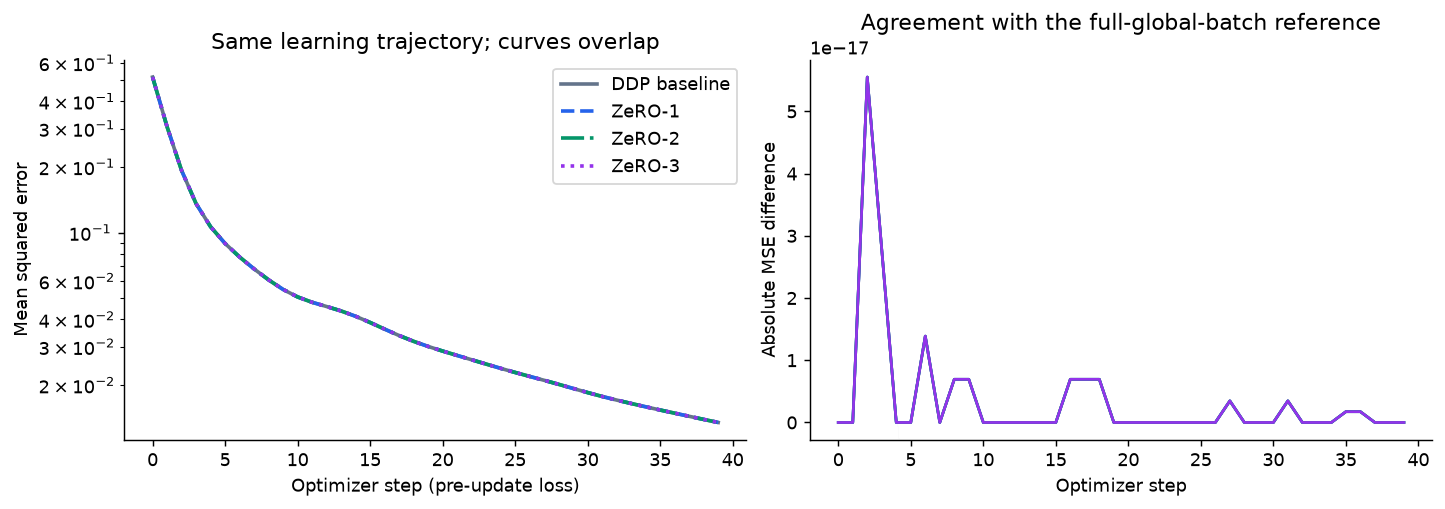

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
reference = np.asarray(results['reference']['loss_curve'])
for i, s in enumerate(stages):
    ax[0].plot(s['loss_curve'], label=s['name'], color=COLORS[i],
               linestyle=['-', '--', '-.', ':'][i], linewidth=2)
    delta = np.abs(np.asarray(s['loss_curve']) - reference)
    ax[1].plot(delta, color=COLORS[i], label=s['name'])
ax[0].set(xlabel='Optimizer step (pre-update loss)', ylabel='Mean squared error',
          title='Same learning trajectory; curves overlap', yscale='log')
ax[0].legend()
ax[1].set(xlabel='Optimizer step', ylabel='Absolute MSE difference',
          title='Agreement with the full-global-batch reference')
fig.savefig(ART / 'plots' / 'training_parity.png', bbox_inches='tight')
plt.show()

## 4. Memory — actual array payload and the paper's precision convention

Let $Q$ be the padded model size, $N=32$, and $P$ the number of useful parameters.
This executable uses float64 throughout for tight numerical comparisons:

| Mode | Persistent allocated state per rank (bytes) |
|---|---|
| DDP | $32Q$ |
| ZeRO-1 | $16Q + 16Q/N$ |
| ZeRO-2 | $8Q + 24Q/N$ |
| ZeRO-3 | $32Q/N$ |

These are **measured from the owned arrays' `nbytes`**. The gradient capacity is
reserved even when zeroed. The tracked peak also includes explicit layer buffers,
activation caches, and backward arrays at instrumentation points. It excludes
coordinator scratch, data/reference models, Python overhead, allocator reservations,
and internal NumPy temporaries; it is **not host RSS or a complete GPU peak**.
Activations remain per-rank, and ZeRO-3 needs a full active layer temporarily.

Separately, the common mixed-precision Adam model assumes 2-byte parameters,
2-byte gradients, and **12 bytes of optimizer state** (4-byte master weights plus
two 4-byte moments). That gives $16P$, $4P+12P/N$, $2P+14P/N$, and $16P/N$.
The projection below uses **one billion parameters**, no padding, and excludes
activations and temporary buffers. It does not claim to train that model here.

| Mode | Actual state KiB/rank | Tracked peak KiB/rank | 1B projected GiB/rank |
|---|---:|---:|---:|
| DDP baseline | 229.000 | 294.000 | 14.901 |
| ZeRO-1 | 118.078 | 139.078 | 4.075 |
| ZeRO-2 | 62.617 | 116.117 | 2.270 |
| ZeRO-3 | 7.156 | 93.156 | 0.466 |

Tracked transient component maxima (bytes/rank; maxima need not coincide):
DDP baseline {'activation_cache': 9216, 'materialized_layer': 0, 'local_gradient': 0, 'backprop_signals': 8192, 'derivative_workspace': 4096, 'optimizer_workspace': 66560}
ZeRO-1 {'activation_cache': 9216, 'materialized_layer': 0, 'local_gradient': 0, 'backprop_signals': 8192, 'derivative_workspace': 4096, 'optimizer_workspace': 2080}
ZeRO-2 {'activation_cache': 9216, 'materialized_layer': 0, 'local_gradient': 33280, 'backprop_signals': 8192, 'derivative_workspace': 4096, 'optimizer_workspace': 2080}
ZeRO-3 {'activation_cache': 9216, 'materialized_layer': 33280, 'local_gradient': 33280, 'backprop_signals': 8192, 'derivative_workspace': 4096, 'optimizer_workspace': 2080}


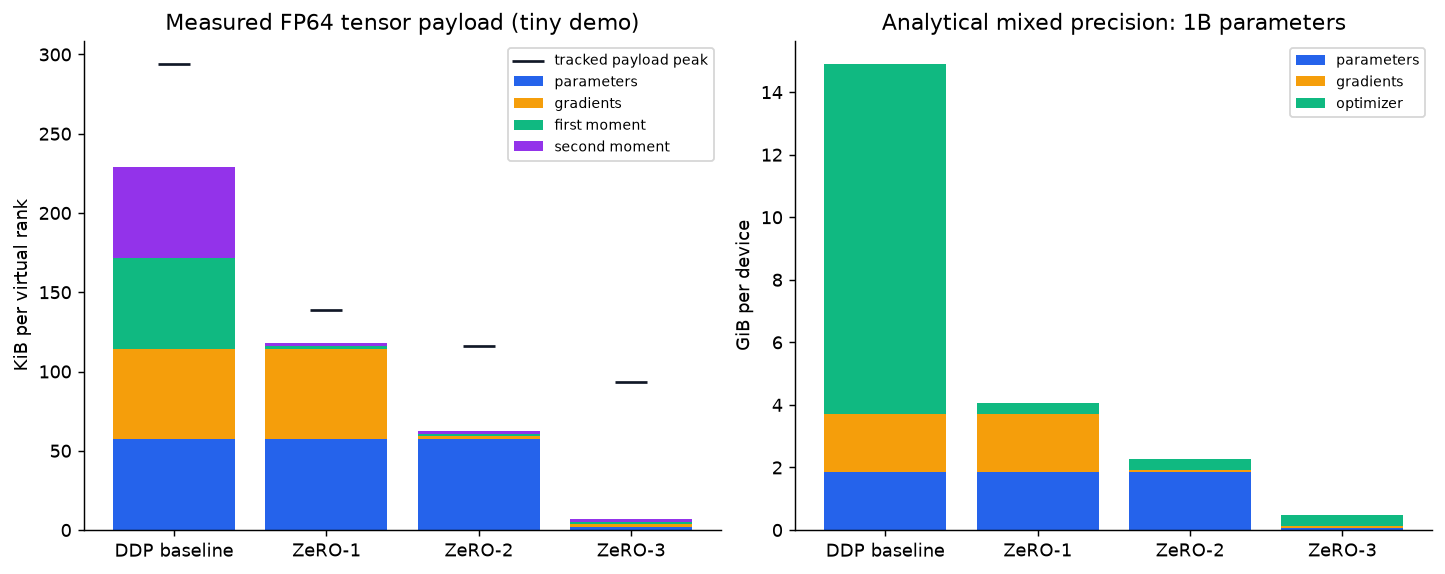

In [6]:
def projected_state(parameter_count, world_size, stage):
    p, n = parameter_count, world_size
    return {'parameters': 2*p/(n if stage >= 3 else 1),
            'gradients': 2*p/(n if stage >= 2 else 1),
            'optimizer': 12*p/(n if stage >= 1 else 1)}

projection_p = 1_000_000_000
theory_rows = []
for s in stages:
    row = {'stage': s['stage'], 'name': s['name'],
           **projected_state(projection_p, N, s['stage'])}
    row['total'] = sum(row[k] for k in ('parameters', 'gradients', 'optimizer'))
    theory_rows.append(row)
results['theory'] = {'parameter_count': projection_p, 'world_size': N,
                    'bytes_per_parameter': {'parameters': 2, 'gradients': 2, 'optimizer': 12},
                    'stages': theory_rows}
rows = ['| Mode | Actual state KiB/rank | Tracked peak KiB/rank | 1B projected GiB/rank |',
        '|---|---:|---:|---:|']
for s, t in zip(stages, theory_rows):
    rows.append(f"| {s['name']} | {s['state_bytes_per_rank']['total']/1024:.3f} | "
                f"{s['peak_tracked_bytes_per_rank']/1024:.3f} | {t['total']/2**30:.3f} |")
display(Markdown('\n'.join(rows)))
print('Tracked transient component maxima (bytes/rank; maxima need not coincide):')
for s in stages:
    print(s['name'], s['transient_component_peaks_per_rank'])

fig, ax = plt.subplots(1, 2, figsize=(11, 4.3), layout='constrained')
labels = [s['name'] for s in stages]
bottom = np.zeros(4)
for key, color in [('parameters', '#2563eb'), ('gradients', '#f59e0b'),
                   ('first_moment', '#10b981'), ('second_moment', '#9333ea')]:
    values = np.array([s['state_bytes_per_rank'][key] for s in stages])/1024
    ax[0].bar(labels, values, bottom=bottom, color=color, label=key.replace('_', ' '))
    bottom += values
ax[0].scatter(labels, [s['peak_tracked_bytes_per_rank']/1024 for s in stages],
              marker='_', s=300, color='#111827', label='tracked payload peak', zorder=5)
ax[0].set(ylabel='KiB per virtual rank', title='Measured FP64 tensor payload (tiny demo)')
ax[0].legend(fontsize=8)
bottom = np.zeros(4)
for key, color in [('parameters', '#2563eb'), ('gradients', '#f59e0b'), ('optimizer', '#10b981')]:
    values = np.array([t[key] for t in theory_rows])/2**30
    ax[1].bar(labels, values, bottom=bottom, color=color, label=key)
    bottom += values
ax[1].set(ylabel='GiB per device', title='Analytical mixed precision: 1B parameters')
ax[1].legend(fontsize=8)
fig.savefig(ART / 'plots' / 'memory_comparison.png', bbox_inches='tight')
plt.show()

## 5. Computation and communication — savings in different places

All ranks still execute **every layer** on their own examples. Sharding storage
does not divide forward/backward arithmetic by 32. Adam, however, updates all $Q$
entries per rank in DDP and only $Q/N$ in each ZeRO stage. Padding entries are
included in this optimizer count; they remain zero.

Matrix multiplication FLOPs count a multiply-add as two operations. Forward is
$2b\sum_l d_l d_{l+1}$. Backward needs a weight-gradient multiplication for every
layer and an input-gradient multiplication except at the input layer. Bias sums,
nonlinearities, loss arithmetic, reduction arithmetic, and Adam operations are
excluded; Adam is reported separately as **elements updated**, not FLOPs.

For a ring, write $q=(N-1)/N$ and $S=8Q$ bytes in this FP64 run. Per-rank **sent**
payload is $qS$ for reduce-scatter or all-gather, and $2qS$ for all-reduce. Thus
DDP/ZeRO-1/ZeRO-2 each send $2qS$ and this release-after-forward ZeRO-3 sends $3qS$.
Received bytes are the same; send+receive is twice these values. This is a
bandwidth-only model: latency, topology, overlap, and protocol overhead are absent.
The event ledger comes from the actual training control flow.

| Mode | Forward matmul FLOPs/rank | Backward matmul FLOPs/rank | Adam entries/rank | Ring sent KiB/rank/step |
|---|---:|---:|---:|---:|
| DDP baseline | 114,688 | 196,608 | 7,328 | 110.922 |
| ZeRO-1 | 114,688 | 196,608 | 229 | 110.922 |
| ZeRO-2 | 114,688 | 196,608 | 229 | 110.922 |
| ZeRO-3 | 114,688 | 196,608 | 229 | 166.383 |

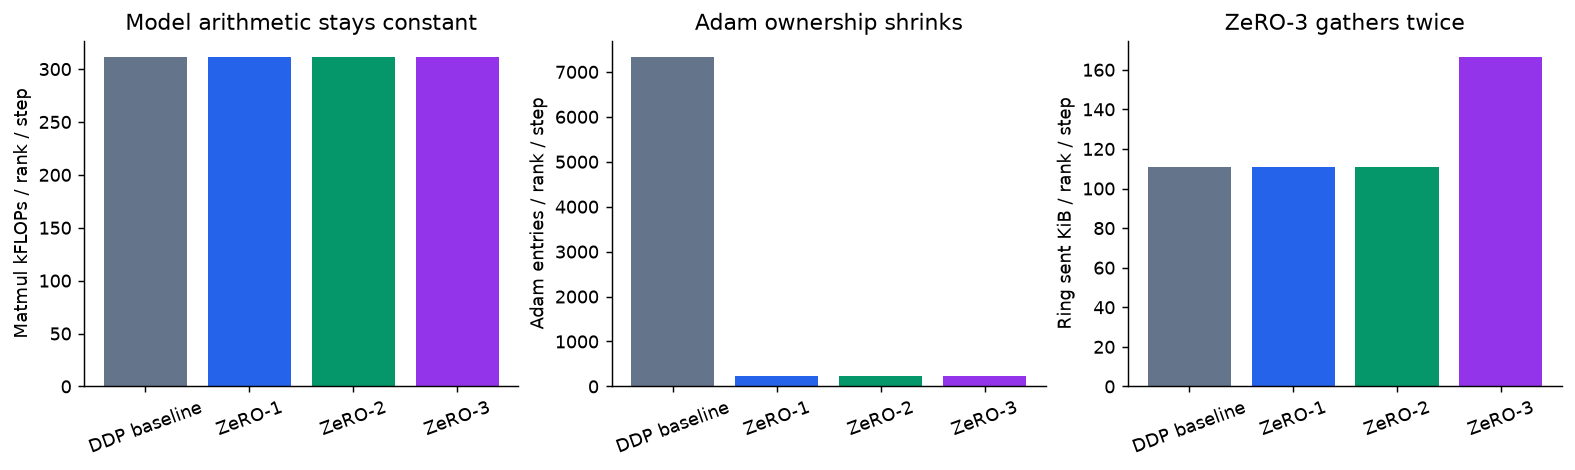

ZeRO-3 first-step collective trace:
[
  {
    "kind": "all_gather",
    "phase": "forward",
    "layer": 0,
    "payload_elements": 2112,
    "payload_bytes": 16896,
    "analytic_bytes_sent_per_rank": 16368
  },
  {
    "kind": "all_gather",
    "phase": "forward",
    "layer": 1,
    "payload_elements": 4160,
    "payload_bytes": 33280,
    "analytic_bytes_sent_per_rank": 32240
  },
  {
    "kind": "all_gather",
    "phase": "forward",
    "layer": 2,
    "payload_elements": 1056,
    "payload_bytes": 8448,
    "analytic_bytes_sent_per_rank": 8184
  },
  {
    "kind": "all_gather",
    "phase": "backward",
    "layer": 2,
    "payload_elements": 1056,
    "payload_bytes": 8448,
    "analytic_bytes_sent_per_rank": 8184
  },
  {
    "kind": "reduce_scatter",
    "phase": "backward",
    "layer": 2,
    "payload_elements": 1056,
    "payload_bytes": 8448,
    "analytic_bytes_sent_per_rank": 8184
  },
  {
    "kind": "all_gather",
    "phase": "backward",
    "layer": 1,
    "payload_ele

In [7]:
rows = ['| Mode | Forward matmul FLOPs/rank | Backward matmul FLOPs/rank | Adam entries/rank | Ring sent KiB/rank/step |',
        '|---|---:|---:|---:|---:|']
for s in stages:
    c = s['computation']
    rows.append(f"| {s['name']} | {c['forward_matmul_flops_per_rank_per_step']:,} | "
                f"{c['backward_matmul_flops_per_rank_per_step']:,} | "
                f"{c['optimizer_element_updates_per_rank_per_step']:,} | "
                f"{s['communication']['bytes_sent_per_rank_per_step']/1024:.3f} |")
display(Markdown('\n'.join(rows)))
fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), layout='constrained')
matmuls = [sum(s['computation'][k] for k in
               ('forward_matmul_flops_per_rank_per_step', 'backward_matmul_flops_per_rank_per_step'))
           for s in stages]
values = [np.array(matmuls)/1e3,
          [s['computation']['optimizer_element_updates_per_rank_per_step'] for s in stages],
          [s['communication']['bytes_sent_per_rank_per_step']/1024 for s in stages]]
for a, v, title, ylabel in zip(ax, values,
        ['Model arithmetic stays constant', 'Adam ownership shrinks', 'ZeRO-3 gathers twice'],
        ['Matmul kFLOPs / rank / step', 'Adam entries / rank / step', 'Ring sent KiB / rank / step']):
    a.bar(labels, v, color=COLORS)
    a.set(title=title, ylabel=ylabel)
    a.tick_params(axis='x', labelrotation=20)
fig.savefig(ART / 'plots' / 'compute_communication.png', bbox_inches='tight')
plt.show()
print('ZeRO-3 first-step collective trace:')
print(json.dumps(stages[3]['communication']['events_first_step'], indent=2))
print('Timing is observed simulator wall time, not a prediction of real GPU speed.')

## 6. What happens when the device count grows?

The following is a **formula sweep**, not additional hardware measurements.
DDP stays flat. ZeRO-1 approaches a 4-byte-per-parameter floor; ZeRO-2 approaches
2 bytes; ZeRO-3's persistent model state scales as 1/N. Full layer gathers and
activations prevent the complete training peak from following that line forever.
At N=1, every stage must reduce to the DDP storage total and zero network traffic.

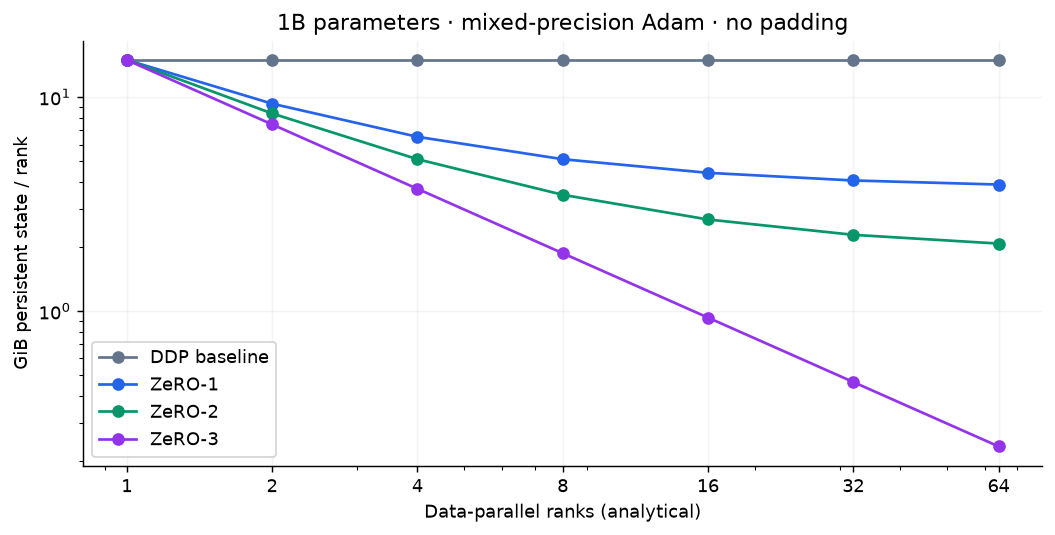

PASS: all four analytical storage models coincide at N=1.


In [8]:
counts = [1, 2, 4, 8, 16, 32, 64]
results['scaling'] = []
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')
for s, color in zip(stages, COLORS):
    memory = []
    for n in counts:
        total = sum(projected_state(projection_p, n, s['stage']).values())
        results['scaling'].append({'world_size': n, 'stage': s['stage'], 'bytes_per_rank': total})
        memory.append(total/2**30)
    ax.plot(counts, memory, 'o-', label=s['name'], color=color)
ax.set(xscale='log', yscale='log', xlabel='Data-parallel ranks (analytical)',
       ylabel='GiB persistent state / rank', title='1B parameters · mixed-precision Adam · no padding')
ax.set_xticks(counts, labels=[str(n) for n in counts])
ax.legend()
ax.grid(alpha=.15)
fig.savefig(ART / 'plots' / 'scaling.png', bbox_inches='tight')
plt.show()
assert all(sum(projected_state(projection_p, 1, s).values()) == 16*projection_p for s in range(4))
print('PASS: all four analytical storage models coincide at N=1.')

## 7. Save reproducible evidence and interpret it

**The result:** the optimizer trajectory stays the same while persistent storage
falls at each stage. ZeRO removes replicated state. It leaves local model arithmetic
unchanged, partitions Adam's work, and in stage 3 trades additional gathers for
parameter memory. The precise timing ordering on this small CPU example is governed
by scheduling and array copies; it is not a GPU throughput benchmark.

Limitations: one process, shared host memory, a deterministic synthetic MLP, no
distributed failure handling, no physical network, no mixed-precision training,
and no CUDA allocation measurement. The fixed local batch keeps activation storage
unchanged between stages. The byte projection excludes activation and temporary
memory. Parameters need not divide evenly: padding is reported explicitly.

Primary references: [ZeRO paper](https://arxiv.org/abs/1910.02054),
[DeepSpeed stage definitions](https://deepspeed.readthedocs.io/en/latest/zero3.html),
[DeepSpeed tutorial](https://www.deepspeed.ai/tutorials/zero/).
The paper's storage convention and the stage definitions inform the simulation;
the numerical outcomes are produced by the cells above.

In [9]:
(ART / 'results.json').write_text(json.dumps(results, indent=2, allow_nan=False) + '\n')
(ART / 'run_config.json').write_text(json.dumps(results['config'], indent=2) + '\n')
print('Saved results.json, run_config.json, and four plots to', ART.resolve())
print('Local verification: python run_demo.py --verify-only && python -m pytest tests -q')

Saved results.json, run_config.json, and four plots to /Users/shankarpandala/projects/era-v5/assignment-12/submission_artifacts
Local verification: python run_demo.py --verify-only && python -m pytest tests -q
